# BCSE331L – Exploratory Data Analysis
## Course Project – Phase 1

**Name:** Rishabh Jain
**Register Number:** 23BDS0254
**Dataset:** Catholic Schools Dataset (NELS-88)






## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## 2. Loading the Dataset



In [3]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/catholic.csv"
df = pd.read_csv(url)
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (7430, 14)


,rownames,id,read12,math12,female,asian,hispan,black,motheduc,fatheduc,lfaminc,hsgrad,cathhs,parcath
0,1,124902,61.41,49.77,0,0,0,0,14.0,12.0,10.30895,1.0,0,1
1,2,124915,58.34,59.84,0,0,0,0,14.0,14.0,10.30895,1.0,0,1
2,3,124916,59.33,50.38,1,0,0,0,14.0,11.0,10.30895,1.0,0,1
3,4,124932,49.59,45.03,1,0,0,0,12.0,14.0,10.30895,1.0,0,1
4,5,124944,57.62,54.26,1,0,0,0,12.0,12.0,10.65726,1.0,0,1


In [62]:
missing_count = df.isnull().sum()

missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
}).sort_values("missing_pct", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
hsgrad,1460,19.65


In [4]:
df.tail()

,rownames,id,read12,math12,female,asian,hispan,black,motheduc,fatheduc,lfaminc,hsgrad,cathhs,parcath
7425,7426,7957692,42.06,56.60,0,0,1,0,16.0,16.0,10.65726,1.0,1,1
7426,7427,7979017,56.44,56.29,1,0,0,1,14.0,16.0,11.04292,1.0,0,1
7427,7428,7979029,56.02,58.16,1,0,0,0,17.0,16.0,10.65726,1.0,0,0
7428,7429,7979082,65.60,61.14,1,0,0,0,12.0,14.0,10.65726,1.0,0,1
7429,7430,7979086,62.80,63.57,0,0,0,0,14.0,16.0,11.04292,1.0,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7430 entries, 0 to 7429
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  7430 non-null   int64  
 1   id        7430 non-null   int64  
 2   read12    7430 non-null   float64
 3   math12    7430 non-null   float64
 4   female    7430 non-null   int64  
 5   asian     7430 non-null   int64  
 6   hispan    7430 non-null   int64  
 7   black     7430 non-null   int64  
 8   motheduc  7430 non-null   float64
 9   fatheduc  7430 non-null   float64
 10  lfaminc   7430 non-null   float64
 11  hsgrad    5970 non-null   float64
 12  cathhs    7430 non-null   int64  
 13  parcath   7430 non-null   int64  
dtypes: float64(6), int64(8)
memory usage: 812.8 KB


## 3. Basic Statistical Analysis



In [6]:
df.dtypes

,0
rownames,int64
id,int64
read12,float64
math12,float64
female,int64
asian,int64
hispan,int64
black,int64
motheduc,float64
fatheduc,float64


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rownames,7430.0,3.715500e+03,2.145001e+03,1.000000,1.858250e+03,3.715500e+03,5.572750e+03,7.430000e+03
id,7430.0,4.589838e+06,2.744467e+06,124902.000000,2.424049e+06,4.592442e+06,7.241106e+06,7.979086e+06
read12,7430.0,5.177240e+01,9.407761e+00,29.150000,4.452500e+01,5.308000e+01,5.947000e+01,6.809000e+01
math12,7430.0,5.213362e+01,9.459117e+00,29.500000,4.502000e+01,5.253000e+01,5.985750e+01,7.137000e+01
female,7430.0,5.173620e-01,4.997321e-01,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
asian,7430.0,5.168237e-02,2.213999e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
hispan,7430.0,1.034993e-01,3.046304e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
black,7430.0,7.065949e-02,2.562724e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
motheduc,7430.0,1.335686e+01,2.005982e+00,8.000000,1.200000e+01,1.400000e+01,1.400000e+01,1.800000e+01
fatheduc,7430.0,1.367416e+01,2.267797e+00,8.000000,1.200000e+01,1.400000e+01,1.600000e+01,1.800000e+01


In [8]:
binary_cols = ["female", "asian", "hispan", "black", "hsgrad", "cathhs", "parcath"]
for col in binary_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- female ---
female
1    3844
0    3586
Name: count, dtype: int64

--- asian ---
asian
0    7046
1     384
Name: count, dtype: int64

--- hispan ---
hispan
0    6661
1     769
Name: count, dtype: int64

--- black ---
black
0    6905
1     525
Name: count, dtype: int64

--- hsgrad ---
hsgrad
1.0    5554
NaN    1460
0.0     416
Name: count, dtype: int64

--- cathhs ---
cathhs
0    6978
1     452
Name: count, dtype: int64

--- parcath ---
parcath
0    4860
1    2570
Name: count, dtype: int64



In [9]:
print("Skewness:\n", df[["read12", "math12"]].skew())
print("\nKurtosis:\n", df[["read12", "math12"]].kurt())

Skewness:
 read12   -0.36695
math12   -0.14642
dtype: float64

Kurtosis:
 read12   -0.834687
math12   -0.875910
dtype: float64


## 4. Handling Missing Data



In [10]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
}).sort_values("missing_pct", ascending=False)
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
hsgrad,1460,19.65


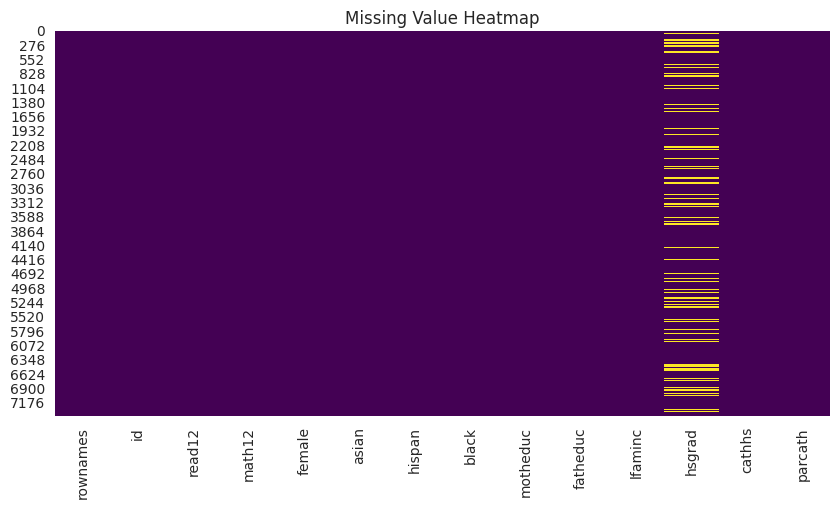

In [11]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

In [12]:
df_clean = df.copy()
for col in ["motheduc", "fatheduc", "lfaminc"]:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
if df_clean["hsgrad"].isnull().sum() > 0:
    mode_val = df_clean["hsgrad"].mode()[0]
    df_clean["hsgrad"] = df_clean["hsgrad"].fillna(mode_val)
df_clean = df_clean.dropna(subset=["read12", "math12"])
print("Missing values after treatment:")
df_clean.isnull().sum()

Missing values after treatment:


,0
rownames,0
id,0
read12,0
math12,0
female,0
asian,0
hispan,0
black,0
motheduc,0
fatheduc,0


## 5. Data Cleaning



In [13]:
print("Fully duplicated rows:", df_clean.duplicated().sum())
print("Duplicate student IDs:", df_clean['id'].duplicated().sum())

Fully duplicated rows: 0
Duplicate student IDs: 0


In [14]:
df_clean = df_clean.drop(columns=["rownames"])
for col in ["female", "asian", "hispan", "black", "hsgrad", "cathhs", "parcath"]:
    df_clean[col] = df_clean[col].astype(int)
df_clean.dtypes

,0
id,int64
read12,float64
math12,float64
female,int64
asian,int64
hispan,int64
black,int64
motheduc,float64
fatheduc,float64
lfaminc,float64


In [15]:
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr
for col in ["read12", "math12"]:
    low, high = iqr_bounds(df_clean[col])
    n_outliers = df_clean[(df_clean[col] < low) | (df_clean[col] > high)].shape[0]
    print(f"{col}: bounds=({low:.2f}, {high:.2f}), outliers={n_outliers}")

read12: bounds=(22.11, 81.89), outliers=0
math12: bounds=(22.76, 82.11), outliers=0


In [16]:
low_r, high_r = iqr_bounds(df_clean["read12"])
low_m, high_m = iqr_bounds(df_clean["math12"])
df_clean["read12_outlier"] = ~df_clean["read12"].between(low_r, high_r)
df_clean["math12_outlier"] = ~df_clean["math12"].between(low_m, high_m)
print("Final cleaned shape:", df_clean.shape)
df_clean.head()

Final cleaned shape: (7430, 15)


,id,read12,math12,female,asian,hispan,black,motheduc,fatheduc,lfaminc,hsgrad,cathhs,parcath,read12_outlier,math12_outlier
0,124902,61.41,49.77,0,0,0,0,14.0,12.0,10.30895,1,0,1,False,False
1,124915,58.34,59.84,0,0,0,0,14.0,14.0,10.30895,1,0,1,False,False
2,124916,59.33,50.38,1,0,0,0,14.0,11.0,10.30895,1,0,1,False,False
3,124932,49.59,45.03,1,0,0,0,12.0,14.0,10.30895,1,0,1,False,False
4,124944,57.62,54.26,1,0,0,0,12.0,12.0,10.65726,1,0,1,False,False


## 6. Data Transformation



In [17]:
def get_race(row):
    if row["asian"] == 1:
        return "Asian"
    elif row["hispan"] == 1:
        return "Hispanic"
    elif row["black"] == 1:
        return "Black"
    else:
        return "White/Other"
df_clean["race"] = df_clean.apply(get_race, axis=1)
df_clean["gender"] = df_clean["female"].map({1: "Female", 0: "Male"})
df_clean["cathhs_label"] = df_clean["cathhs"].map({1: "Catholic HS", 0: "Non-Catholic HS"})
df_clean["avg_parent_educ"] = df_clean[["motheduc", "fatheduc"]].mean(axis=1)
df_clean["avg_score"] = df_clean[["read12", "math12"]].mean(axis=1)
df_clean["approx_family_income"] = np.exp(df_clean["lfaminc"])
df_clean[["race", "gender", "cathhs_label", "avg_parent_educ", "avg_score", "approx_family_income"]].head()

,race,gender,cathhs_label,avg_parent_educ,avg_score,approx_family_income
0,White/Other,Male,Non-Catholic HS,13.0,55.590,29999.920181
1,White/Other,Male,Non-Catholic HS,14.0,59.090,29999.920181
2,White/Other,Female,Non-Catholic HS,12.5,54.855,29999.920181
3,White/Other,Female,Non-Catholic HS,13.0,47.310,29999.920181
4,White/Other,Female,Non-Catholic HS,12.0,55.940,42500.027416


In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_clean[["read12_scaled", "math12_scaled"]] = scaler.fit_transform(df_clean[["read12", "math12"]])
df_clean[["read12", "read12_scaled", "math12", "math12_scaled"]].head()

,read12,read12_scaled,math12,math12_scaled
0,61.41,0.828454,49.77,0.484118
1,58.34,0.749615,59.84,0.724624
2,59.33,0.775039,50.38,0.498686
3,49.59,0.524910,45.03,0.370910
4,57.62,0.731125,54.26,0.591354


## 7. Univariate Analysis



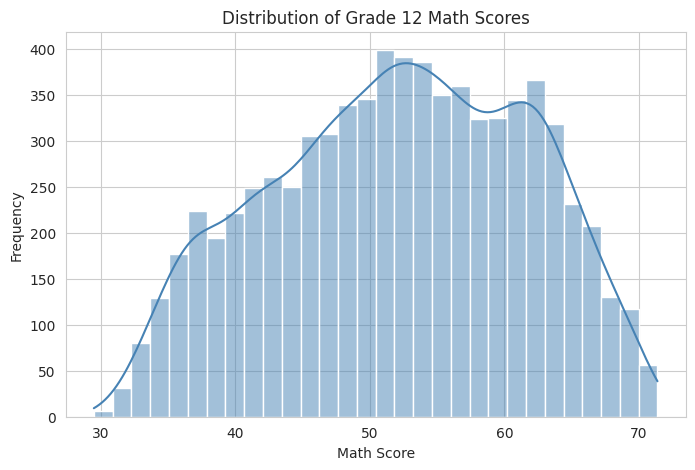

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["math12"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Grade 12 Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

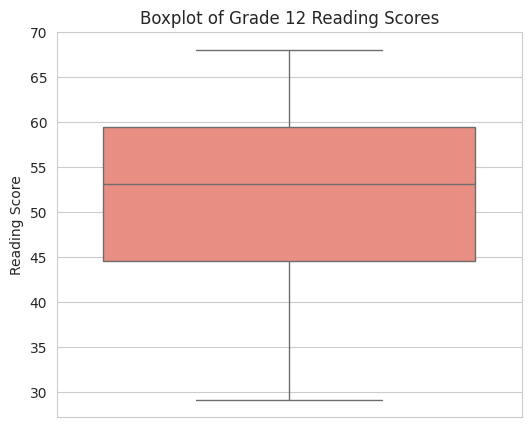

In [20]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=df_clean["read12"], color="salmon")
plt.title("Boxplot of Grade 12 Reading Scores")
plt.ylabel("Reading Score")
plt.show()

/tmp/ipykernel_570/3014425549.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="race", data=df_clean, order=df_clean["race"].value_counts().index, palette="viridis")


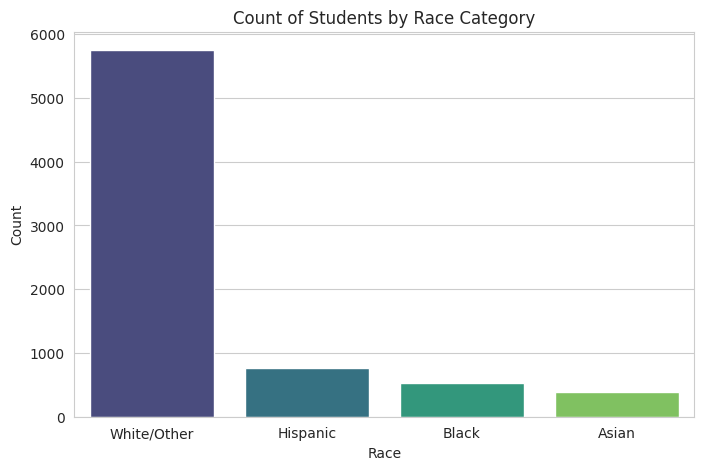

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(x="race", data=df_clean, order=df_clean["race"].value_counts().index, palette="viridis")
plt.title("Count of Students by Race Category")
plt.xlabel("Race")
plt.ylabel("Count")
plt.show()

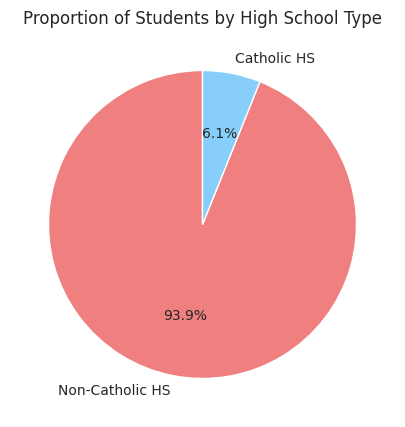

In [22]:
plt.figure(figsize=(6, 5))
df_clean["cathhs_label"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90,
                                                   colors=["lightcoral", "lightskyblue"])
plt.title("Proportion of Students by High School Type")
plt.ylabel("")
plt.show()

## 8. Bivariate Analysis



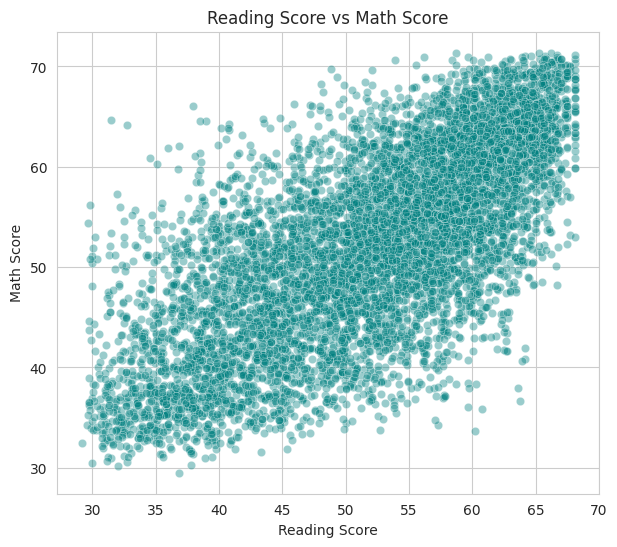

In [23]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x="read12", y="math12", data=df_clean, alpha=0.4, color="teal")
plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.show()

/tmp/ipykernel_570/1416675637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cathhs_label", y="math12", data=df_clean, palette="Set2")


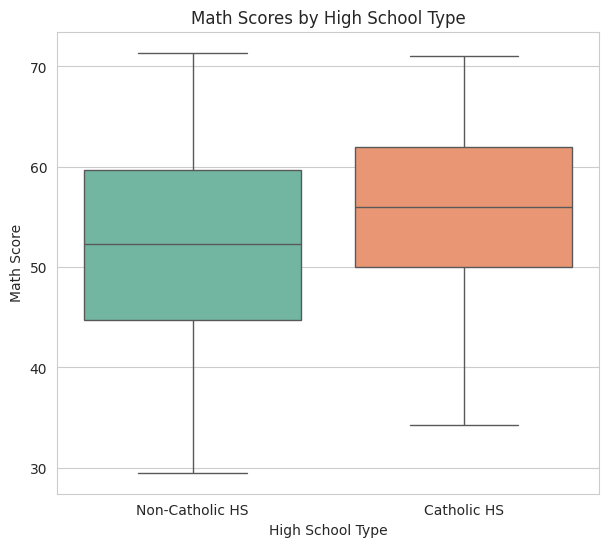

In [24]:
plt.figure(figsize=(7, 6))
sns.boxplot(x="cathhs_label", y="math12", data=df_clean, palette="Set2")
plt.title("Math Scores by High School Type")
plt.xlabel("High School Type")
plt.ylabel("Math Score")
plt.show()

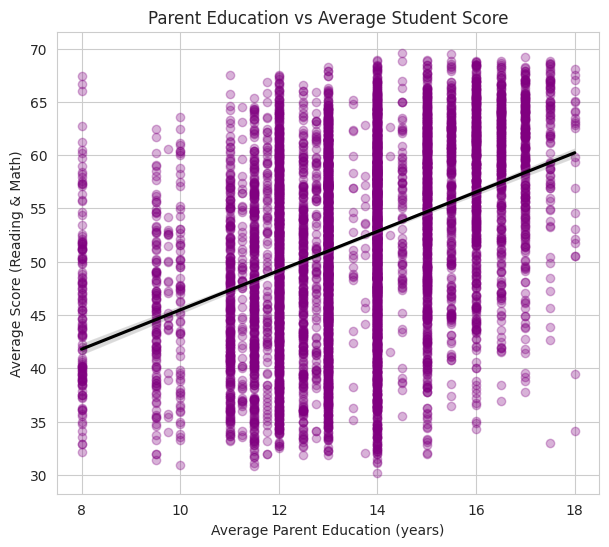

In [25]:
plt.figure(figsize=(7, 6))
sns.regplot(x="avg_parent_educ", y="avg_score", data=df_clean,
            scatter_kws={"alpha": 0.3, "color": "purple"}, line_kws={"color": "black"})
plt.title("Parent Education vs Average Student Score")
plt.xlabel("Average Parent Education (years)")
plt.ylabel("Average Score (Reading & Math)")
plt.show()

/tmp/ipykernel_570/2886112061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="gender", y="math12", data=df_clean, palette="pastel")


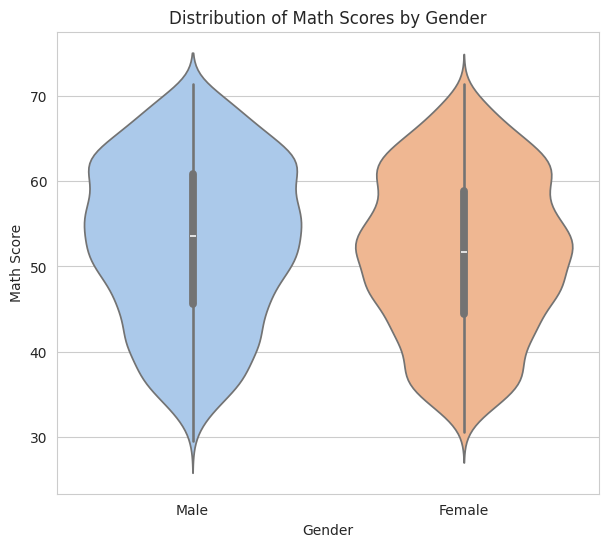

In [26]:
plt.figure(figsize=(7, 6))
sns.violinplot(x="gender", y="math12", data=df_clean, palette="pastel")
plt.title("Distribution of Math Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.show()

## 9. Multivariate Analysis



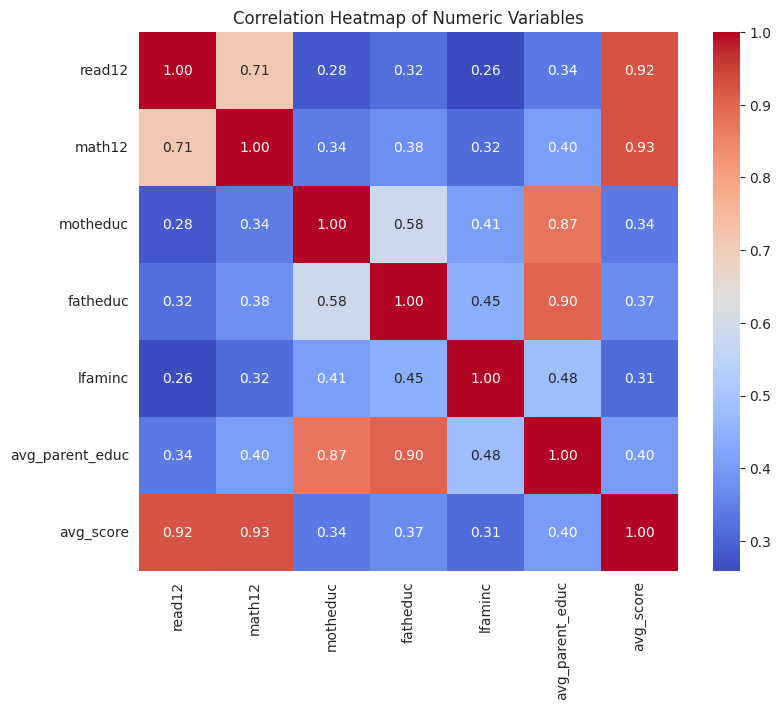

In [27]:
numeric_cols = ["read12", "math12", "motheduc", "fatheduc", "lfaminc", "avg_parent_educ", "avg_score"]
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

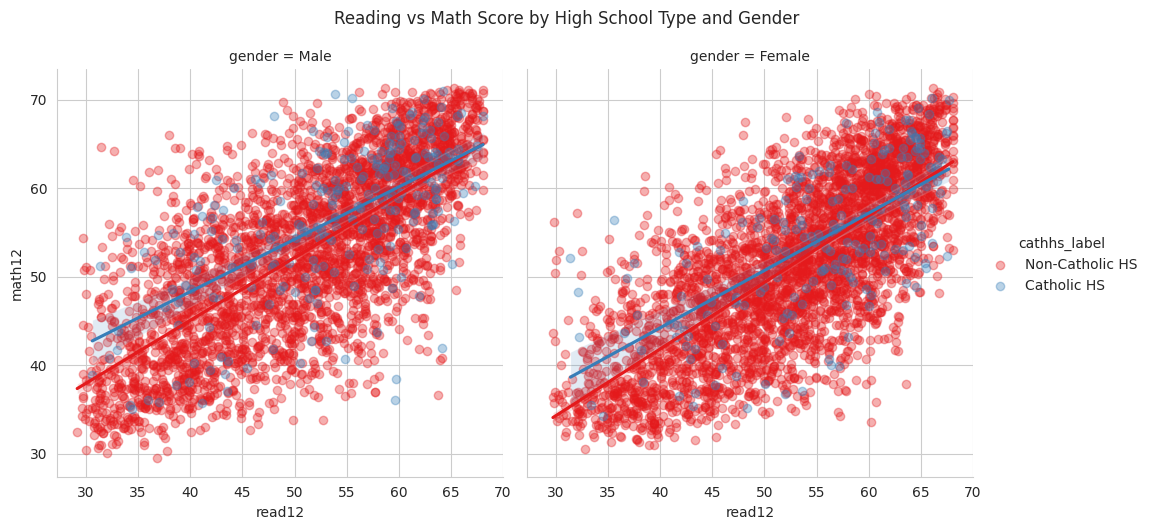

In [28]:
g = sns.lmplot(x="read12", y="math12", hue="cathhs_label", col="gender",
                data=df_clean, height=5, aspect=1, scatter_kws={"alpha": 0.35},
                palette="Set1")
g.fig.suptitle("Reading vs Math Score by High School Type and Gender", y=1.05)
plt.show()

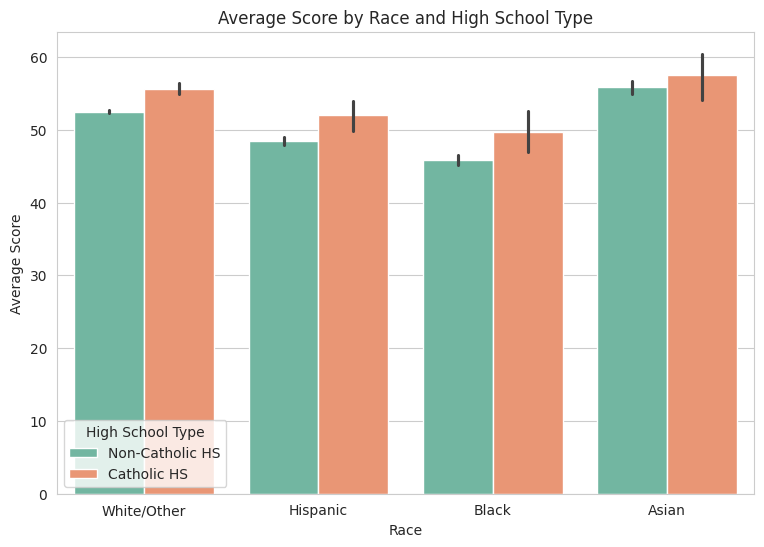

In [29]:
plt.figure(figsize=(9, 6))
sns.barplot(x="race", y="avg_score", hue="cathhs_label", data=df_clean,
            estimator=np.mean, palette="Set2")
plt.title("Average Score by Race and High School Type")
plt.xlabel("Race")
plt.ylabel("Average Score")
plt.legend(title="High School Type")
plt.show()

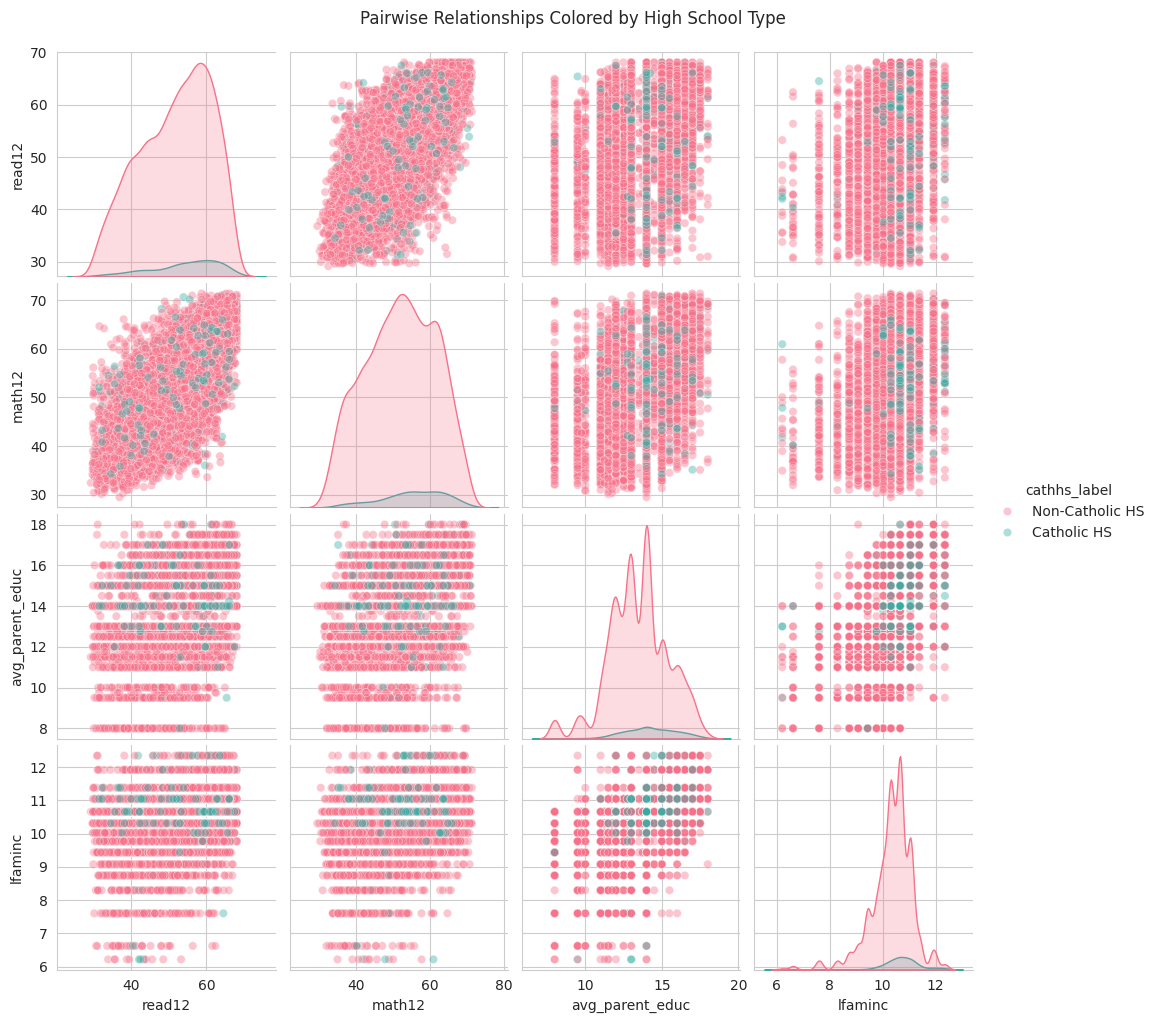

In [30]:
sns.pairplot(df_clean, vars=["read12", "math12", "avg_parent_educ", "lfaminc"],
             hue="cathhs_label", palette="husl", diag_kind="kde", plot_kws={"alpha": 0.4})
plt.suptitle("Pairwise Relationships Colored by High School Type", y=1.02)
plt.show()

# PHASE II – ASSESSMENT 2







In [31]:
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
print("Phase II libraries imported successfully.")
print("Cleaned dataset shape:", df_clean.shape)

Phase II libraries imported successfully.
Cleaned dataset shape: (7430, 23)


# 1. 1D Statistical Analysis



In [32]:
numeric_cols_phase2 = df_clean.select_dtypes(include=np.number).columns.tolist()
preferred_numeric = [
    "read12", "math12", "motheduc", "fatheduc",
    "lfaminc", "avg_parent_educ", "avg_score"
]
numeric_cols_phase2 = [c for c in preferred_numeric if c in df_clean.columns]
print("Variables used for 1D analysis:")
print(numeric_cols_phase2)
df_numeric_phase2 = df_clean[numeric_cols_phase2].copy()
display(df_numeric_phase2.describe().T)

Variables used for 1D analysis:
['read12', 'math12', 'motheduc', 'fatheduc', 'lfaminc', 'avg_parent_educ', 'avg_score']


,count,mean,std,min,25%,50%,75%,max
read12,7430.0,51.772402,9.407761,29.150000,44.52500,53.08000,59.47000,68.09000
math12,7430.0,52.133623,9.459117,29.500000,45.02000,52.53000,59.85750,71.37000
motheduc,7430.0,13.356864,2.005982,8.000000,12.00000,14.00000,14.00000,18.00000
fatheduc,7430.0,13.674159,2.267797,8.000000,12.00000,14.00000,16.00000,18.00000
lfaminc,7430.0,10.353323,0.794519,6.214608,10.02127,10.30895,10.65726,12.34583
avg_parent_educ,7430.0,13.515511,1.902149,8.000000,12.00000,14.00000,15.00000,18.00000
avg_score,7430.0,51.953013,8.723803,30.195000,45.44000,52.58500,59.00375,69.60500


In [33]:
central_tendency = pd.DataFrame({
    "Mean": df_numeric_phase2.mean(),
    "Median": df_numeric_phase2.median(),
    "Mode": df_numeric_phase2.mode().iloc[0]
})
display(central_tendency)

,Mean,Median,Mode
read12,51.772402,53.08000,68.09000
math12,52.133623,52.53000,50.73000
motheduc,13.356864,14.00000,14.00000
fatheduc,13.674159,14.00000,14.00000
lfaminc,10.353323,10.30895,10.65726
avg_parent_educ,13.515511,14.00000,14.00000
avg_score,51.953013,52.58500,41.69500


In [34]:
dispersion = pd.DataFrame({
    "Variance": df_numeric_phase2.var(),
    "Standard Deviation": df_numeric_phase2.std(),
    "Range": df_numeric_phase2.max() - df_numeric_phase2.min(),
    "Minimum": df_numeric_phase2.min(),
    "Maximum": df_numeric_phase2.max()
})
display(dispersion)

,Variance,Standard Deviation,Range,Minimum,Maximum
read12,88.505967,9.407761,38.940000,29.150000,68.09000
math12,89.474901,9.459117,41.870000,29.500000,71.37000
motheduc,4.023964,2.005982,10.000000,8.000000,18.00000
fatheduc,5.142905,2.267797,10.000000,8.000000,18.00000
lfaminc,0.631260,0.794519,6.131222,6.214608,12.34583
avg_parent_educ,3.618172,1.902149,10.000000,8.000000,18.00000
avg_score,76.104746,8.723803,39.410000,30.195000,69.60500


In [35]:
distribution_shape = pd.DataFrame({
    "Skewness": df_numeric_phase2.skew(),
    "Kurtosis": df_numeric_phase2.kurtosis()
})
display(distribution_shape)

,Skewness,Kurtosis
read12,-0.366950,-0.834687
math12,-0.146420,-0.875910
motheduc,-0.304348,0.370579
fatheduc,-0.164345,-0.165084
lfaminc,-1.185925,3.870098
avg_parent_educ,-0.233726,0.240284
avg_score,-0.238510,-0.821525


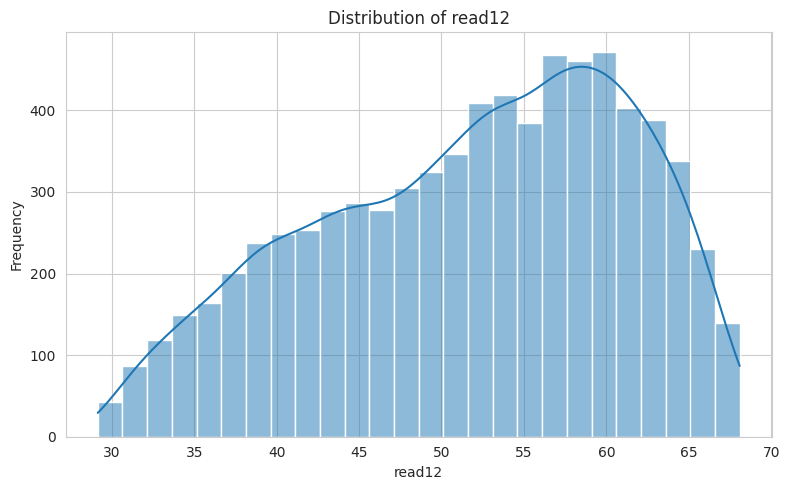

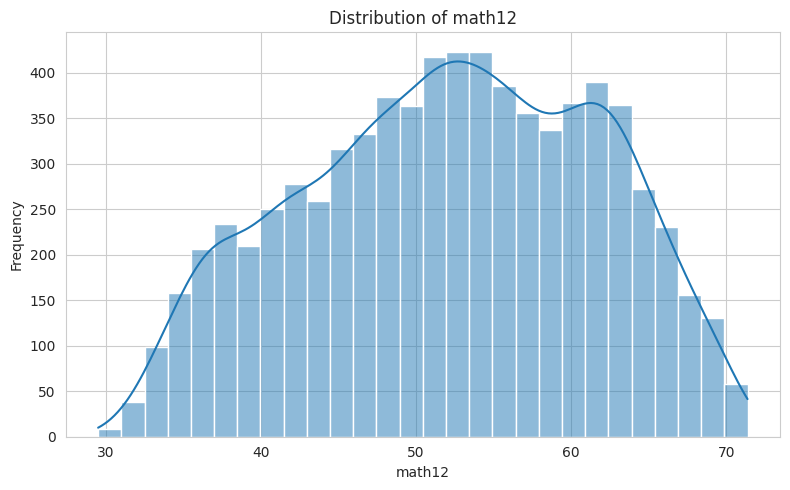

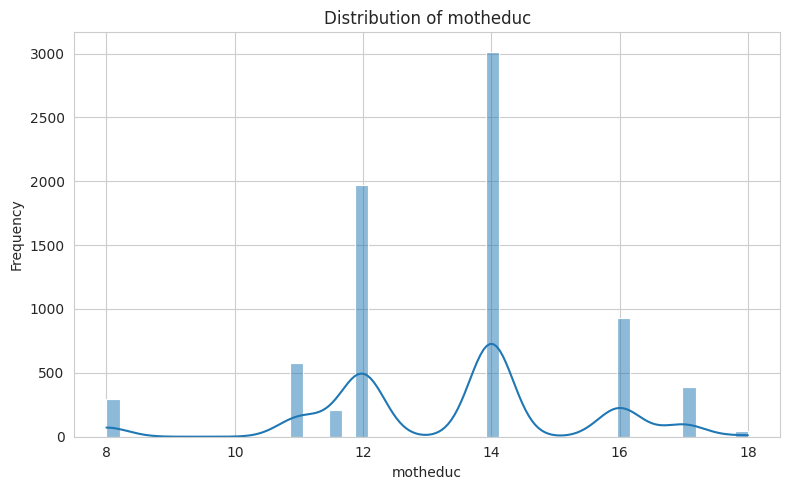

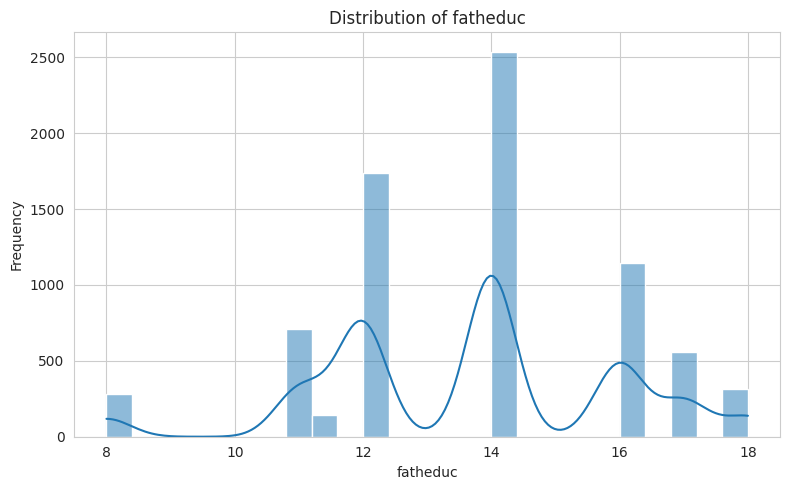

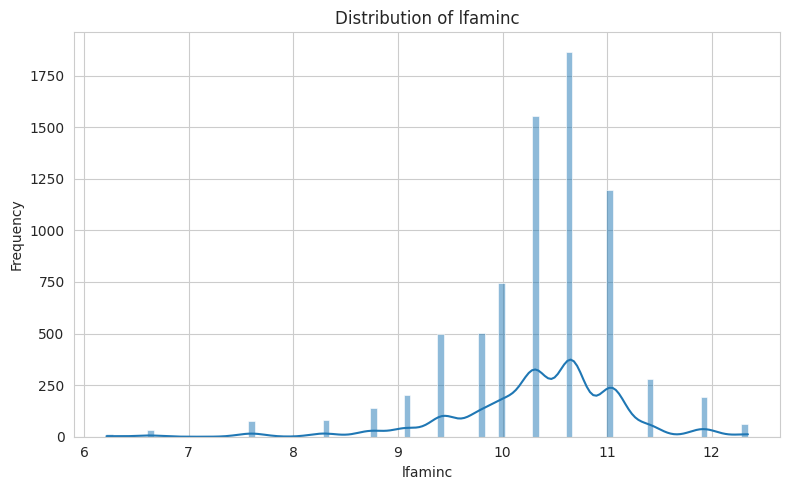

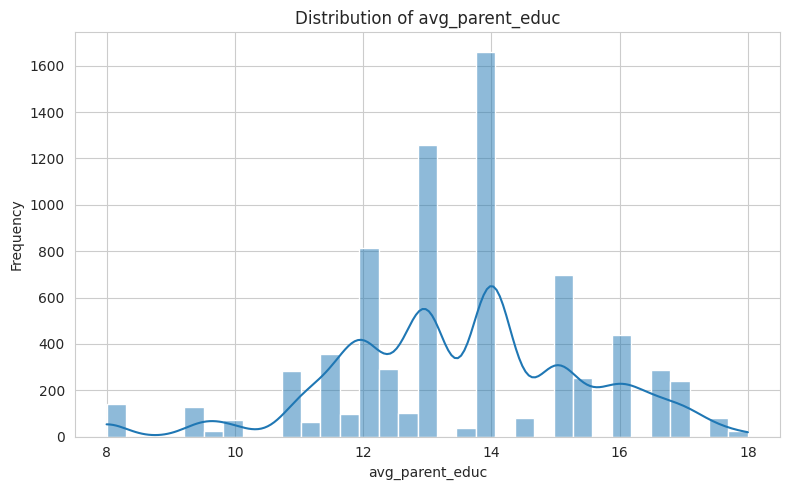

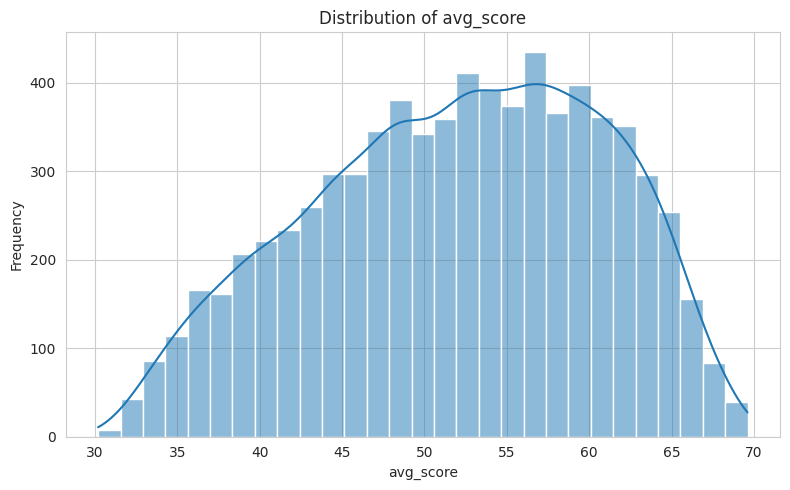

In [36]:
for column in numeric_cols_phase2:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_clean[column].dropna(), kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

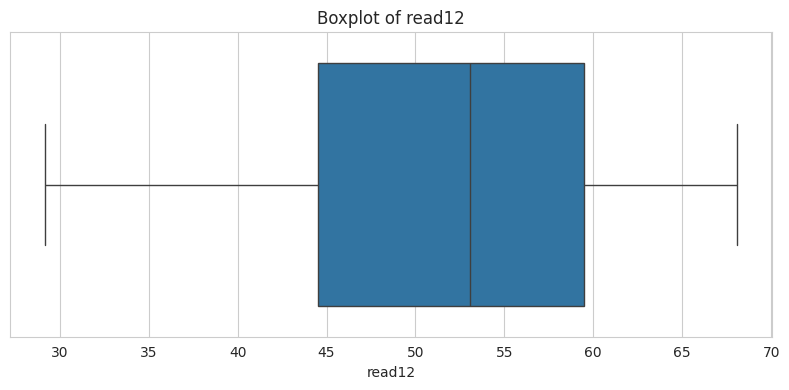

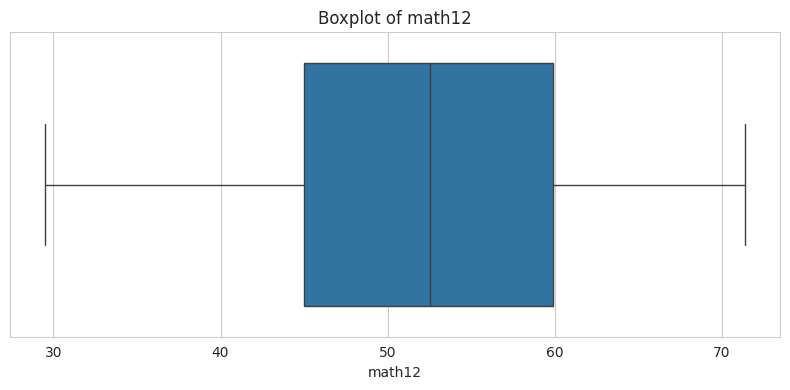

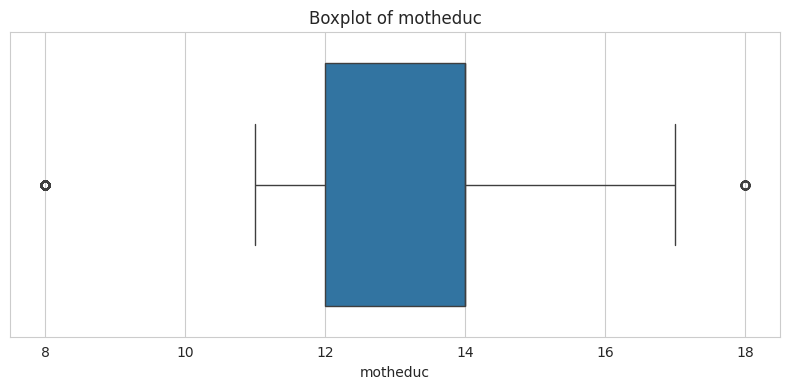

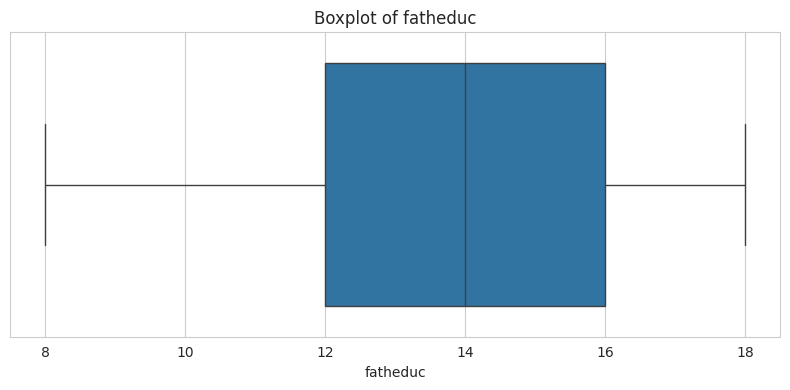

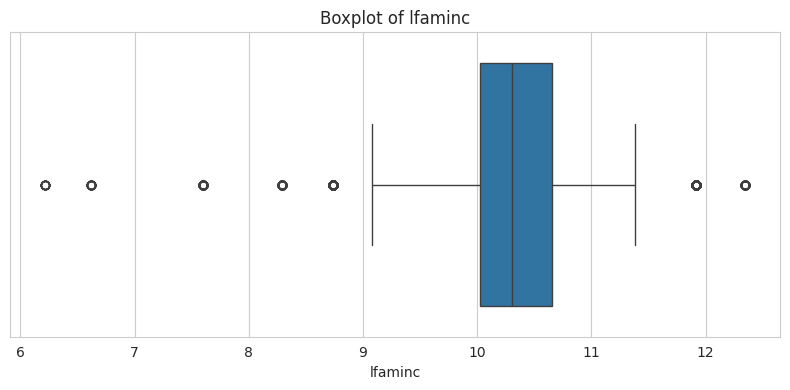

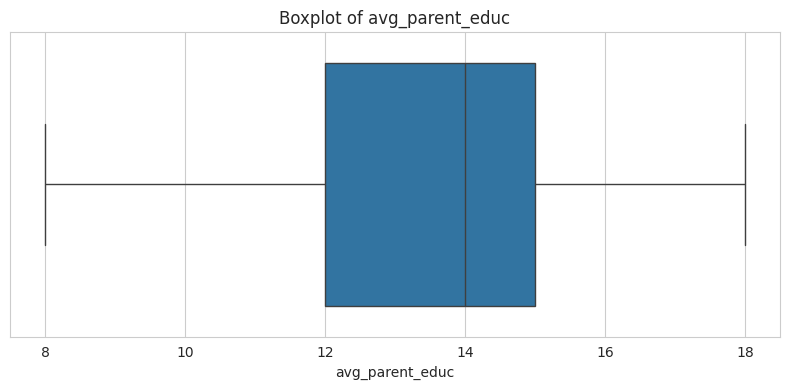

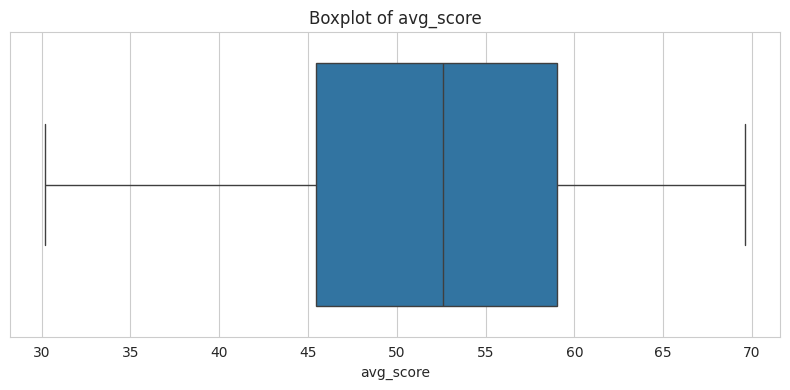

In [37]:
for column in numeric_cols_phase2:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_clean[column].dropna())
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

# 2. 2D Statistical Analysis



In [38]:
covariance_matrix = df_numeric_phase2.cov()
display(covariance_matrix)

,read12,math12,motheduc,fatheduc,lfaminc,avg_parent_educ,avg_score
read12,88.505967,63.219057,5.370789,6.763690,1.933271,6.067240,75.862512
math12,63.219057,89.474901,6.495048,8.050261,2.377175,7.272654,76.346979
motheduc,5.370789,6.495048,4.023964,2.652910,0.645849,3.338437,5.932919
fatheduc,6.763690,8.050261,2.652910,5.142905,0.803897,3.897907,7.406976
lfaminc,1.933271,2.377175,0.645849,0.803897,0.631260,0.724873,2.155223
avg_parent_educ,6.067240,7.272654,3.338437,3.897907,0.724873,3.618172,6.669947
avg_score,75.862512,76.346979,5.932919,7.406976,2.155223,6.669947,76.104746


In [39]:
correlation_matrix = df_numeric_phase2.corr()
display(correlation_matrix)

,read12,math12,motheduc,fatheduc,lfaminc,avg_parent_educ,avg_score
read12,1.000000,0.710413,0.284593,0.317025,0.258644,0.339047,0.924347
math12,0.710413,1.000000,0.342298,0.375280,0.316305,0.404201,0.925199
motheduc,0.284593,0.342298,1.000000,0.583165,0.405228,0.874926,0.339028
fatheduc,0.317025,0.375280,0.583165,1.000000,0.446161,0.903613,0.374396
lfaminc,0.258644,0.316305,0.405228,0.446161,1.000000,0.479637,0.310944
avg_parent_educ,0.339047,0.404201,0.874926,0.903613,0.479637,1.000000,0.401950
avg_score,0.924347,0.925199,0.339028,0.374396,0.310944,0.401950,1.000000


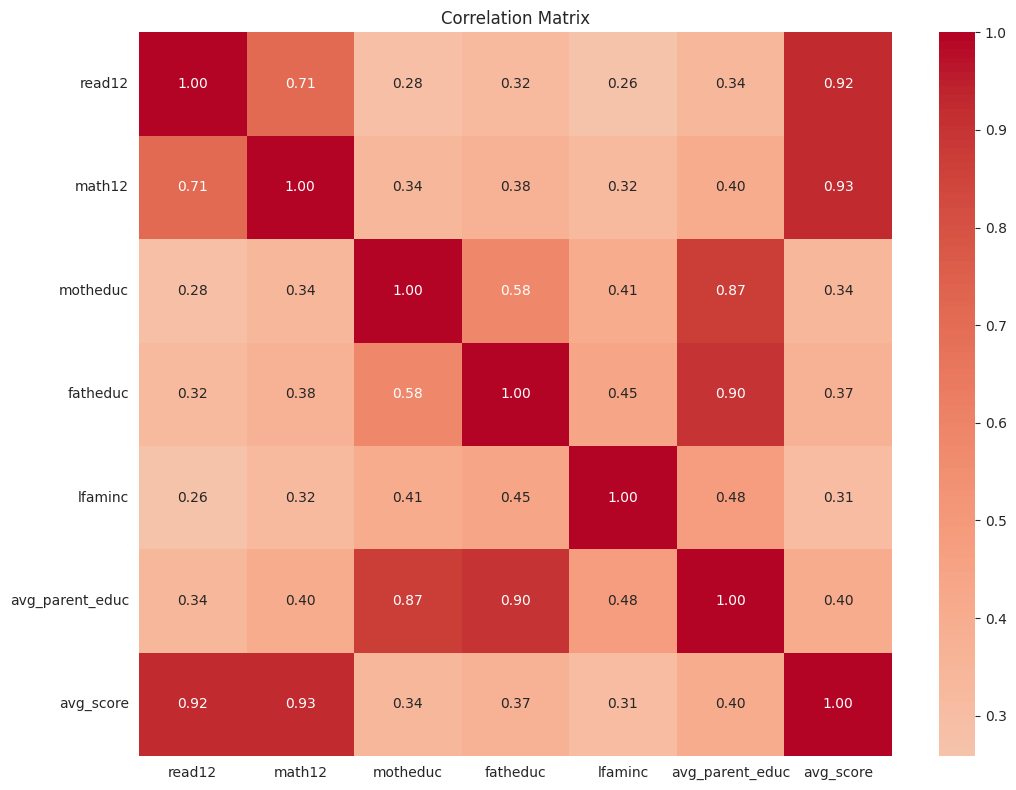

In [40]:
plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [41]:
preferred_pairs = [
    ("read12", "math12"),
    ("motheduc", "avg_score"),
    ("fatheduc", "avg_score"),
    ("lfaminc", "avg_score"),
    ("avg_parent_educ", "avg_score")
]
pairs_phase2 = [
    (x, y) for x, y in preferred_pairs
    if x in df_clean.columns and y in df_clean.columns
]
print("Pairs used:", pairs_phase2)

Pairs used: [('read12', 'math12'), ('motheduc', 'avg_score'), ('fatheduc', 'avg_score'), ('lfaminc', 'avg_score'), ('avg_parent_educ', 'avg_score')]


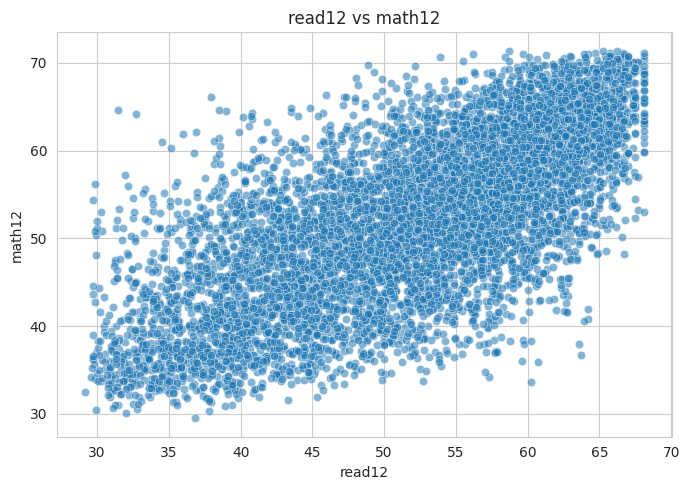

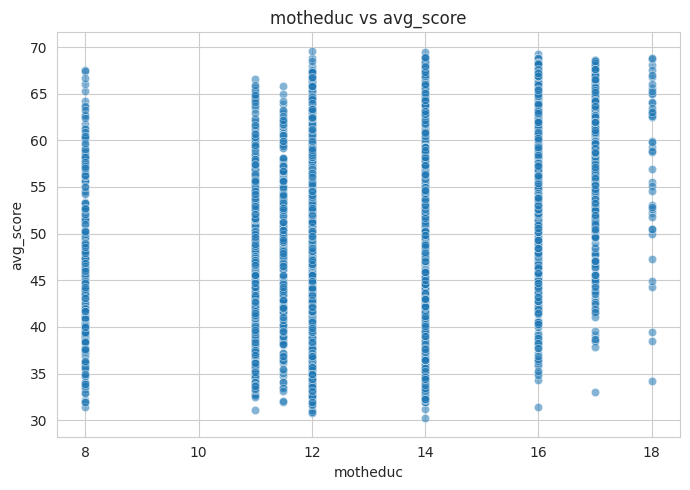

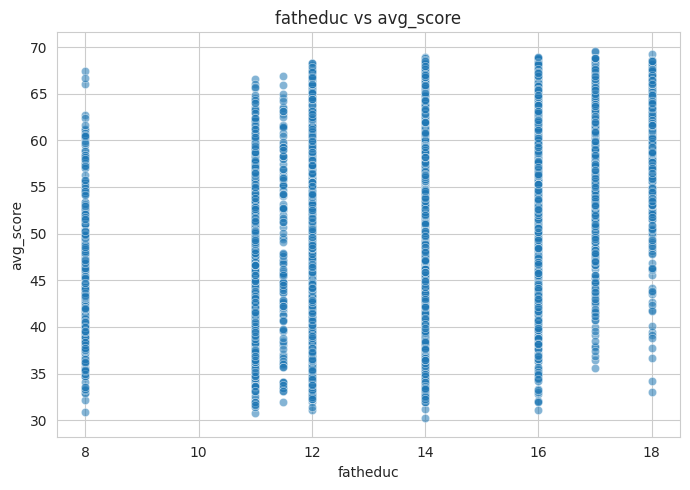

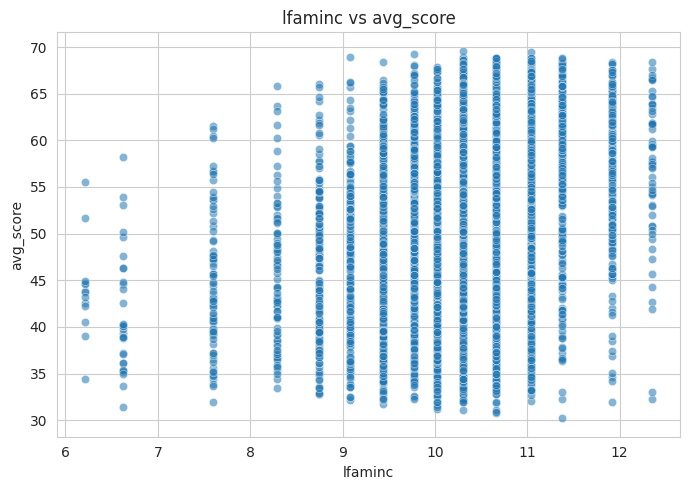

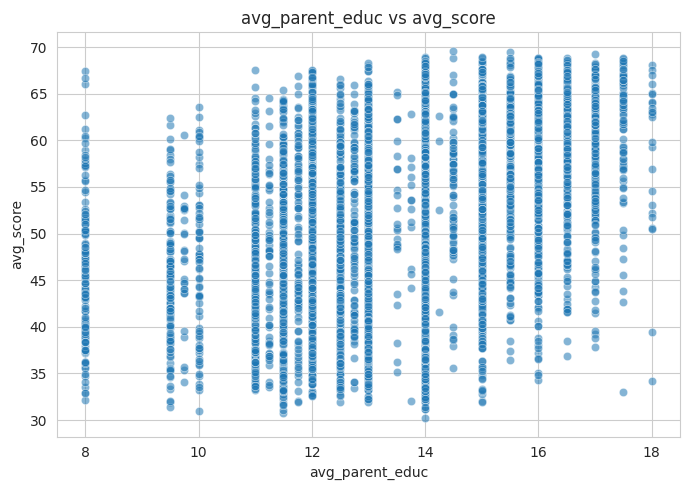

In [42]:
for x, y in pairs_phase2:
    temp = df_clean[[x, y]].dropna()
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=temp, x=x, y=y, alpha=0.55)
    plt.title(f"{x} vs {y}")
    plt.tight_layout()
    plt.show()

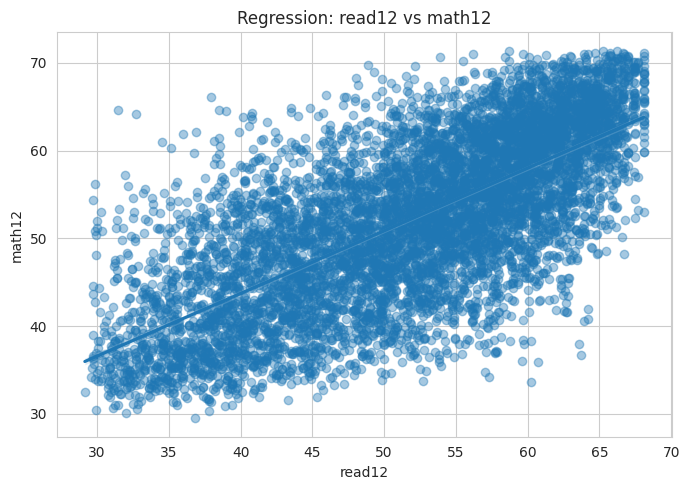

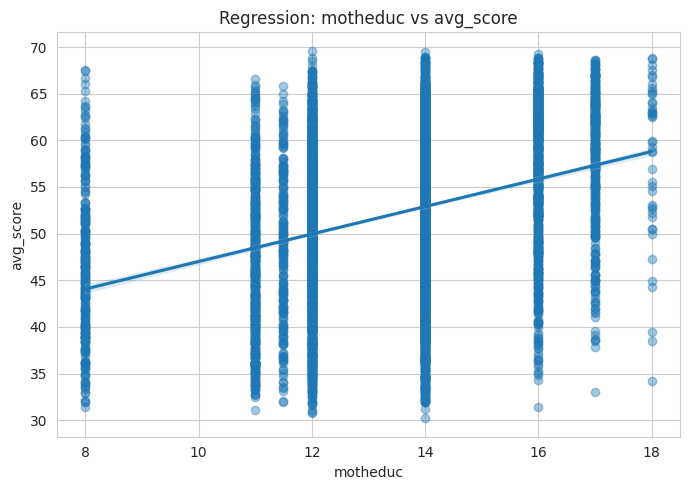

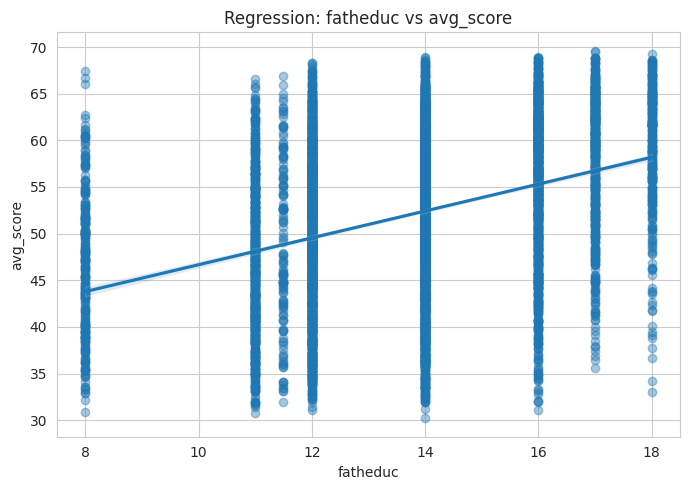

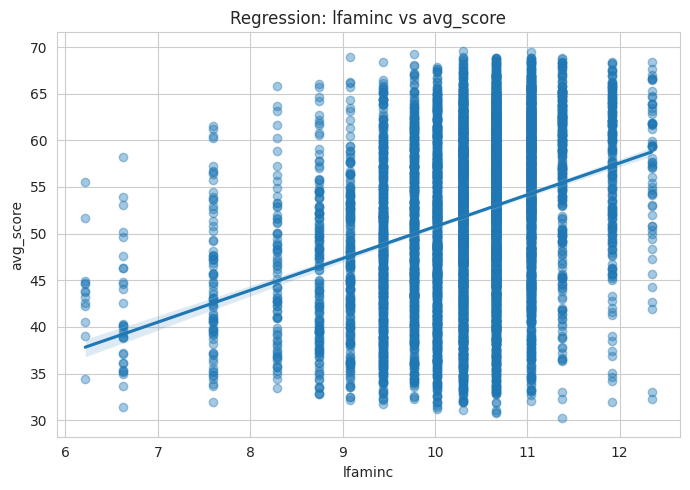

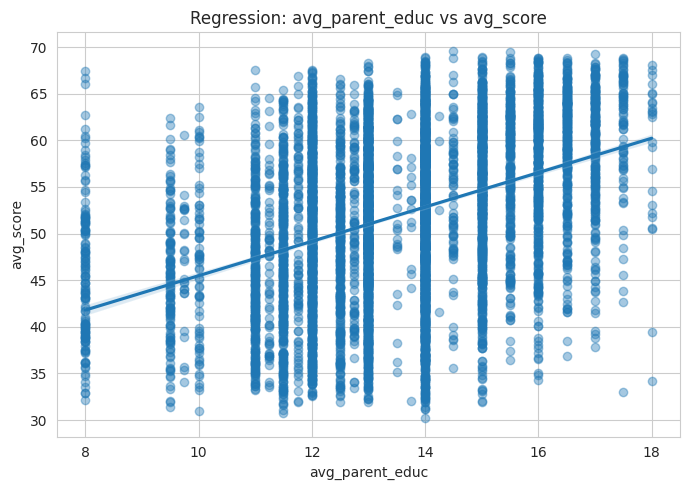

In [43]:
for x, y in pairs_phase2:
    temp = df_clean[[x, y]].dropna()
    plt.figure(figsize=(7, 5))
    sns.regplot(
        data=temp,
        x=x,
        y=y,
        scatter_kws={"alpha": 0.4}
    )
    plt.title(f"Regression: {x} vs {y}")
    plt.tight_layout()
    plt.show()

In [44]:
pearson_results = []
for x, y in pairs_phase2:
    temp = df_clean[[x, y]].dropna()
    if len(temp) >= 3:
        r, p = stats.pearsonr(temp[x], temp[y])
        pearson_results.append({
            "Variable 1": x,
            "Variable 2": y,
            "Pearson r": r,
            "p-value": p
        })
pearson_results = pd.DataFrame(pearson_results)
display(pearson_results)

,Variable 1,Variable 2,Pearson r,p-value
0,read12,math12,0.710413,0.000000e+00
1,motheduc,avg_score,0.339028,3.108556e-199
2,fatheduc,avg_score,0.374396,6.269229e-246
3,lfaminc,avg_score,0.310944,2.871192e-166
4,avg_parent_educ,avg_score,0.401950,1.348471e-286


# 3. 3D Statistical Analysis



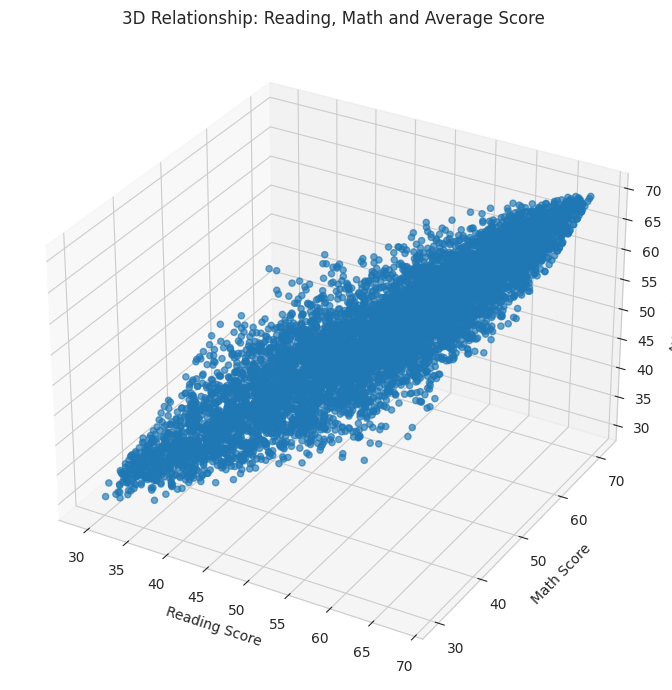

In [45]:
required = ["read12", "math12", "avg_score"]
if all(c in df_clean.columns for c in required):
    temp = df_clean[required].dropna()
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(
        temp["read12"],
        temp["math12"],
        temp["avg_score"],
        alpha=0.65
    )
    ax.set_xlabel("Reading Score")
    ax.set_ylabel("Math Score")
    ax.set_zlabel("Average Score")
    ax.set_title("3D Relationship: Reading, Math and Average Score")
    plt.tight_layout()
    plt.show()
else:
    print("Required variables for the academic 3D plot are unavailable.")

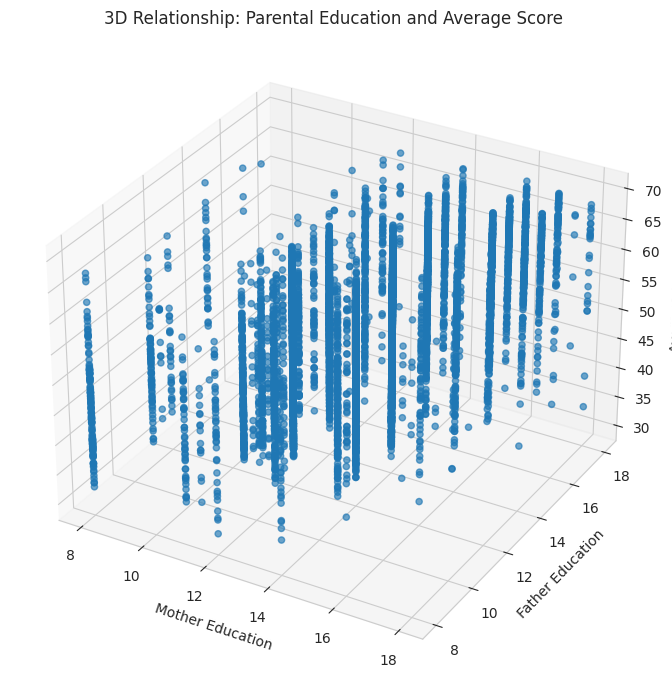

In [46]:
required = ["motheduc", "fatheduc", "avg_score"]
if all(c in df_clean.columns for c in required):
    temp = df_clean[required].dropna()
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(
        temp["motheduc"],
        temp["fatheduc"],
        temp["avg_score"],
        alpha=0.65
    )
    ax.set_xlabel("Mother Education")
    ax.set_ylabel("Father Education")
    ax.set_zlabel("Average Score")
    ax.set_title("3D Relationship: Parental Education and Average Score")
    plt.tight_layout()
    plt.show()
else:
    print("Required variables for the parental 3D plot are unavailable.")

# 4. K-Means Clustering




In [47]:
preferred_cluster_features = [
    "read12", "math12", "motheduc",
    "fatheduc", "lfaminc", "avg_score"
]
cluster_features = [
    c for c in preferred_cluster_features
    if c in df_clean.columns
]
if len(cluster_features) < 2:
    cluster_features = numeric_cols_phase2[:6]
X = df_clean[cluster_features].dropna().copy()
print("Clustering features:", cluster_features)
print("Rows used:", len(X))

Clustering features: ['read12', 'math12', 'motheduc', 'fatheduc', 'lfaminc', 'avg_score']
Rows used: 7430


In [48]:
cluster_scaler = StandardScaler()
X_scaled = cluster_scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=cluster_features,
    index=X.index
)
display(X_scaled_df.head())

,read12,math12,motheduc,fatheduc,lfaminc,avg_score
0,1.024499,-0.249895,0.320631,-0.738281,-0.055853,0.416932
1,0.698151,0.814758,0.320631,0.143691,-0.055853,0.818160
2,0.803391,-0.185402,0.320631,-1.179267,-0.055853,0.332674
3,-0.231995,-0.751032,-0.676454,0.143691,-0.055853,-0.532259
4,0.621613,0.224812,-0.676454,-0.738281,0.382568,0.457055


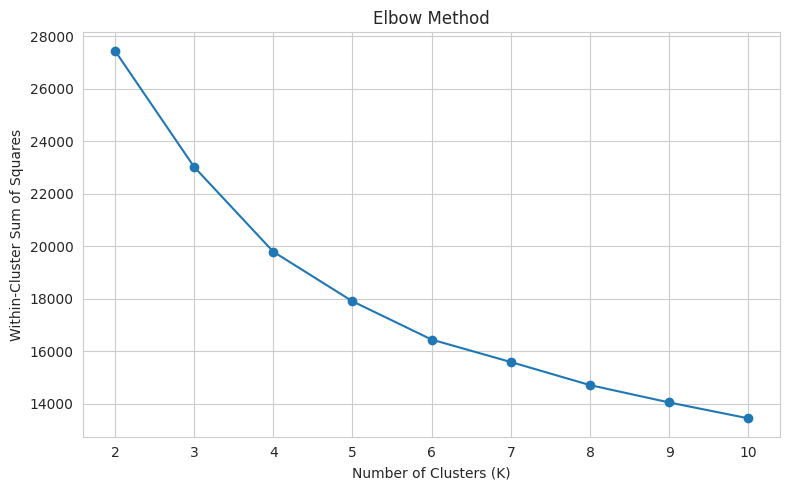

In [49]:
inertia = []
k_values = range(2, 11)
for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

In [50]:
optimal_k = 3
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
kmeans_labels = kmeans.fit_predict(X_scaled)
X_kmeans = X.copy()
X_kmeans["KMeans_Cluster"] = kmeans_labels
display(X_kmeans.head())

,read12,math12,motheduc,fatheduc,lfaminc,avg_score,KMeans_Cluster
0,61.41,49.77,14.0,12.0,10.30895,55.590,1
1,58.34,59.84,14.0,14.0,10.30895,59.090,1
2,59.33,50.38,14.0,11.0,10.30895,54.855,1
3,49.59,45.03,12.0,14.0,10.30895,47.310,0
4,57.62,54.26,12.0,12.0,10.65726,55.940,1


In [51]:
kmeans_sizes = (
    X_kmeans["KMeans_Cluster"]
    .value_counts()
    .sort_index()
    .rename("Number of Observations")
)
display(kmeans_sizes)

,Number of Observations
KMeans_Cluster,
0,2475
1,2819
2,2136


In [52]:
cluster_centers = pd.DataFrame(
    cluster_scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features
)
cluster_centers.index = [
    f"Cluster {i}" for i in range(optimal_k)
]
display(cluster_centers)

,read12,math12,motheduc,fatheduc,lfaminc,avg_score
Cluster 0,41.448331,42.309600,12.483428,12.593169,9.993135,41.878965
Cluster 1,55.192054,54.333129,12.753636,12.911493,10.264427,54.762591
Cluster 2,59.213561,60.605419,15.163781,15.931680,10.887579,59.909490


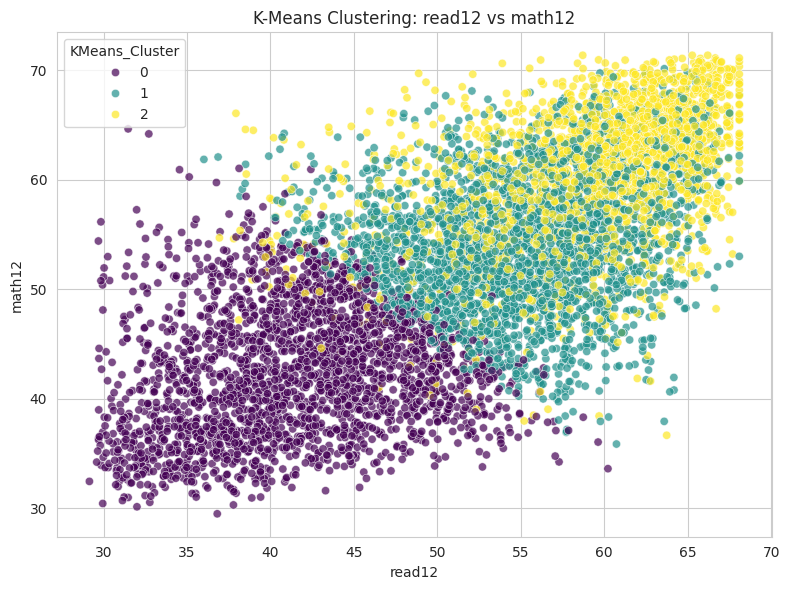

In [53]:
if len(cluster_features) >= 2:
    x_col, y_col = cluster_features[0], cluster_features[1]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=X_kmeans,
        x=x_col,
        y=y_col,
        hue="KMeans_Cluster",
        palette="viridis",
        alpha=0.7
    )
    plt.title(f"K-Means Clustering: {x_col} vs {y_col}")
    plt.tight_layout()
    plt.show()

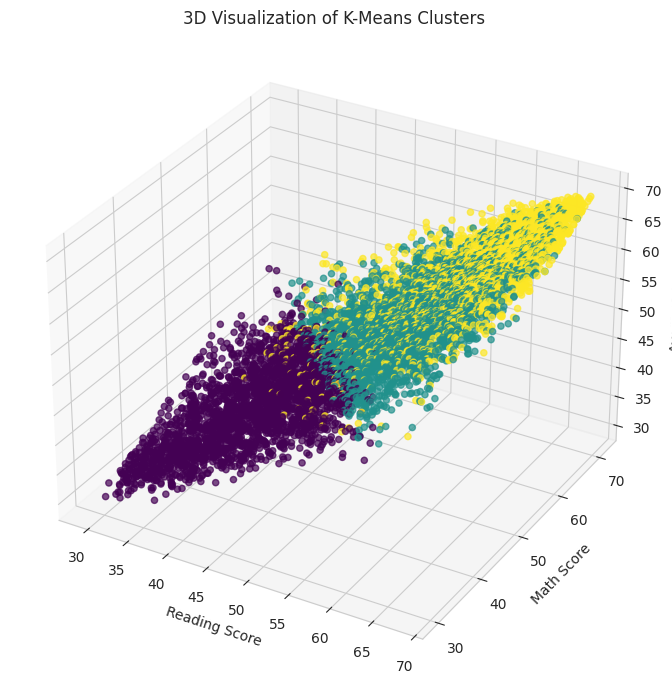

In [54]:
required = ["read12", "math12", "avg_score"]
if all(c in X_kmeans.columns for c in required):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(
        X_kmeans["read12"],
        X_kmeans["math12"],
        X_kmeans["avg_score"],
        c=X_kmeans["KMeans_Cluster"],
        cmap="viridis",
        alpha=0.7
    )
    ax.set_xlabel("Reading Score")
    ax.set_ylabel("Math Score")
    ax.set_zlabel("Average Score")
    ax.set_title("3D Visualization of K-Means Clusters")
    plt.tight_layout()
    plt.show()

# 5. Hierarchical Clustering




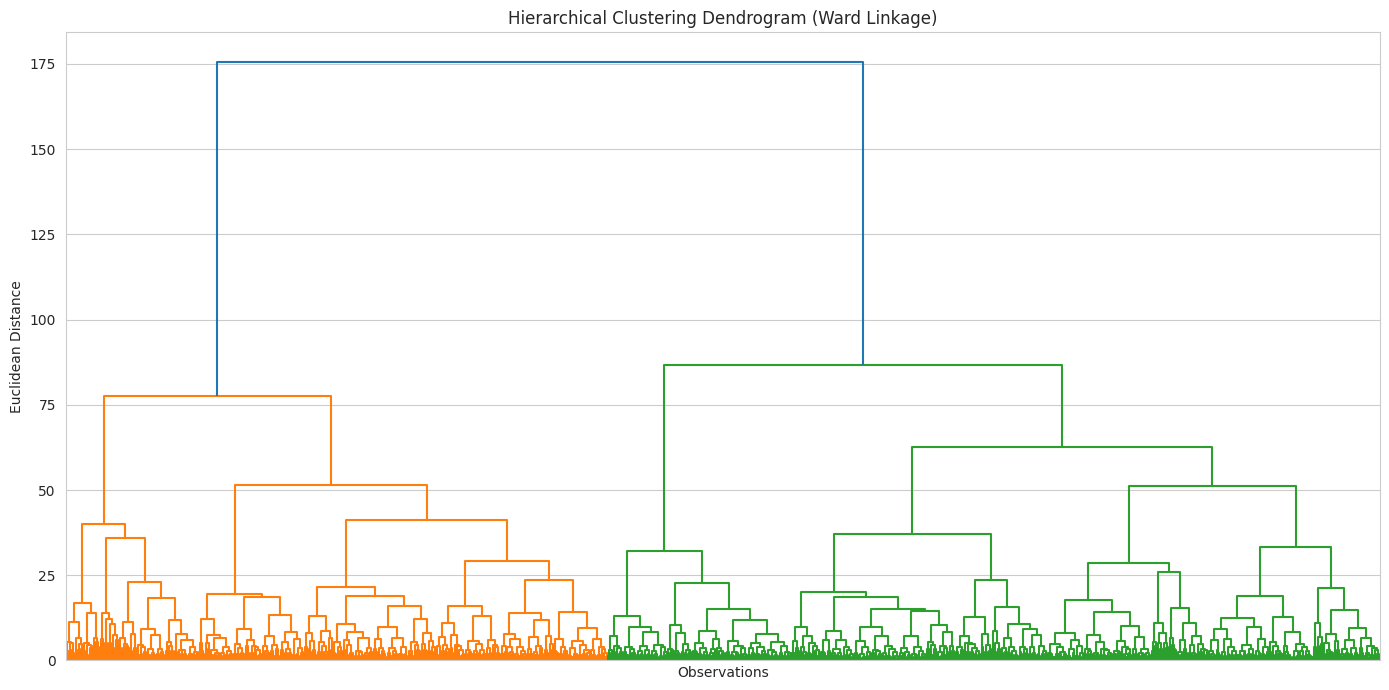

In [55]:
linked = linkage(
    X_scaled,
    method="ward"
)
plt.figure(figsize=(14, 7))
dendrogram(linked, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Observations")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

In [56]:
hierarchical = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage="ward"
)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
X_hierarchical = X.copy()
X_hierarchical["Hierarchical_Cluster"] = hierarchical_labels
display(X_hierarchical.head())

,read12,math12,motheduc,fatheduc,lfaminc,avg_score,Hierarchical_Cluster
0,61.41,49.77,14.0,12.0,10.30895,55.590,1
1,58.34,59.84,14.0,14.0,10.30895,59.090,1
2,59.33,50.38,14.0,11.0,10.30895,54.855,1
3,49.59,45.03,12.0,14.0,10.30895,47.310,0
4,57.62,54.26,12.0,12.0,10.65726,55.940,1


In [57]:
hierarchical_sizes = (
    X_hierarchical["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
    .rename("Number of Observations")
)
display(hierarchical_sizes)

,Number of Observations
Hierarchical_Cluster,
0,3066
1,3325
2,1039


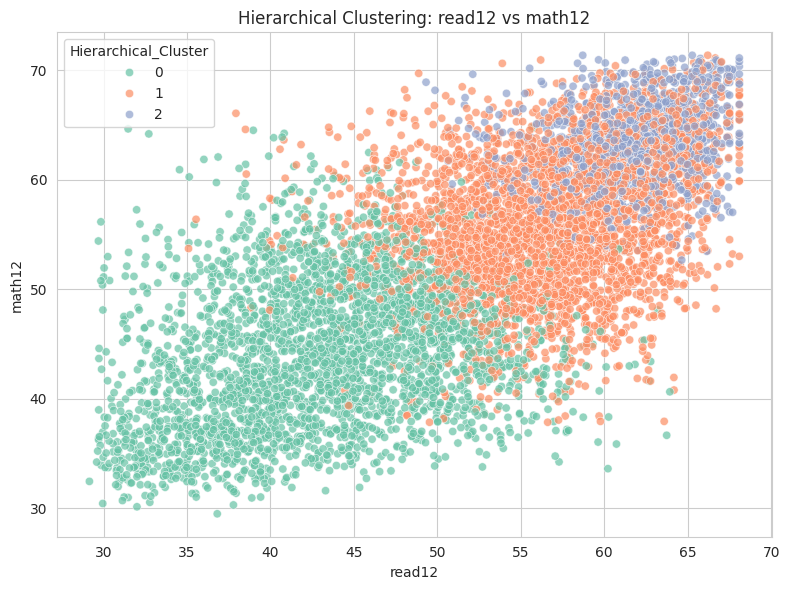

In [58]:
if len(cluster_features) >= 2:
    x_col, y_col = cluster_features[0], cluster_features[1]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=X_hierarchical,
        x=x_col,
        y=y_col,
        hue="Hierarchical_Cluster",
        palette="Set2",
        alpha=0.7
    )
    plt.title(f"Hierarchical Clustering: {x_col} vs {y_col}")
    plt.tight_layout()
    plt.show()

# 6. Comparison of Clustering Results


In [59]:
comparison_summary = pd.DataFrame({
    "K-Means": kmeans_sizes,
    "Hierarchical": hierarchical_sizes
}).fillna(0).astype(int)
display(comparison_summary)

,K-Means,Hierarchical
0,2475,3066
1,2819,3325
2,2136,1039


In [60]:
cluster_comparison = pd.DataFrame({
    "KMeans_Cluster": kmeans_labels,
    "Hierarchical_Cluster": hierarchical_labels
}, index=X.index)
display(cluster_comparison.head(10))

,KMeans_Cluster,Hierarchical_Cluster
0,1,1
1,1,1
2,1,1
3,0,0
4,1,1
5,1,1
6,1,1
7,2,1
8,0,0
9,1,1
